# 🎬 CinePredict — Advanced ML Pipeline
## Movie Rating Tier Prediction · Professional Research Notebook

---

| Item | Detail |
|---|---|
| **Dataset** | 10,000 Top-Rated TMDB Movies |
| **Target** | 3-Class: Average / Good / Excellent |
| **Total Models** | 14 (9 baseline + XGBoost + LightGBM + 3 tuned/ensemble) |
| **Hyperparameter Tuning** | Optuna Bayesian Optimisation (TPE Sampler) |
| **Visualizations** | 13 publication-quality research plots |
| **Persistence** | All models saved as `.pkl` — instant Flask serving |
| **Best Model** | **RF (Tuned)** — Accuracy 0.6075 |

---


## 📦 Step 1 — Imports & Environment

In [3]:
import pandas as pd
import numpy as np
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc, matthews_corrcoef
)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

CLASSES   = ['Average', 'Good', 'Excellent']
PALETTE   = ['#ff5e2c','#ffbe0b','#56cfb2','#5b8dd9','#c084fc','#f472b6','#34d399','#fb923c','#a78bfa']
CLR_MAP   = {'Baseline':'#5b8dd9','Boosting':'#ff5e2c','Tuned':'#ffbe0b','Ensemble':'#56cfb2'}
CLASS_CLR = {'Average':'#5b8dd9','Good':'#56cfb2','Excellent':'#ff5e2c'}

plt.rcParams.update({
    'figure.facecolor':'#0a0a0f', 'axes.facecolor':'#111118', 'axes.edgecolor':'#2a2a3a',
    'axes.labelcolor':'#c0c0d0',  'xtick.color':'#6b6b80',    'ytick.color':'#6b6b80',
    'text.color':'#f0f0f5',       'grid.color':'#1e1e2e',     'grid.linewidth':0.5,
    'axes.titlesize':12,          'axes.labelsize':10,
})
os.makedirs('models', exist_ok=True)
print(f"XGBoost v{xgb.__version__} | LightGBM v{lgb.__version__} | Optuna v{optuna.__version__}")
print("Environment ready")


XGBoost v3.2.0 | LightGBM v4.6.0 | Optuna v4.8.0
Environment ready


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.3 MB/s eta 0:00:00


## 📊 Step 2 — Data Loading

In [9]:
df = pd.read_csv('/content/top_rated_movies.csv')
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.describe().round(3)


Shape  : (10000, 10)
Columns: ['adult', 'id', 'original_language', 'original_title', 'overview', 'popularity', 'release_date', 'title', 'vote_average', 'vote_count']

Missing values:
adult                0
id                   0
original_language    0
original_title       0
overview             2
popularity           0
release_date         3
title                0
vote_average         0
vote_count           0
dtype: int64


,id,popularity,vote_average,vote_count
count,10000.000,10000.000,10000.000,10000.000
mean,228994.990,5.245,6.743,2102.697
std,304776.902,9.624,0.648,3359.868
min,2.000,0.007,5.500,300.000
25%,10375.750,2.604,6.237,475.000
50%,41666.500,3.766,6.710,869.000
75%,408456.250,5.873,7.215,2113.250
max,1472638.000,589.097,8.718,39461.000


In [10]:
# ── Feature Engineering ───────────────────────────────────────────────
df['release_year']    = pd.to_datetime(df['release_date'], errors='coerce').dt.year.fillna(2000)
df['movie_age']       = 2024 - df['release_year']
top5                  = df['original_language'].value_counts().nlargest(5).index
df['lang_group']      = df['original_language'].apply(lambda x: x if x in top5 else 'other')
le                    = LabelEncoder()
df['lang_enc']        = le.fit_transform(df['lang_group'])
df['is_english']      = (df['original_language'] == 'en').astype(int)
df['log_vote_count']  = np.log1p(df['vote_count'])
df['log_popularity']  = np.log1p(df['popularity'])
df['overview_length'] = df['overview'].fillna('').apply(len)
df['word_count']      = df['overview'].fillna('').apply(lambda x: len(x.split()))
df['pop_x_votes']     = df['log_popularity'] * df['log_vote_count']
df['age_x_votes']     = df['movie_age']      * df['log_vote_count']

df['rating_tier'] = pd.cut(df['vote_average'], bins=[5.4,6.5,7.5,9.0],
                            labels=['Average','Good','Excellent'])
df = df.dropna(subset=['rating_tier'])
df['rating_tier'] = df['rating_tier'].astype(str)

FEATURES = ['log_popularity','log_vote_count','movie_age','lang_enc','is_english',
            'overview_length','word_count','pop_x_votes','age_x_votes']

print(f"Engineered shape: {df.shape}")
print(f"\nClass distribution:")
for cls, cnt in df['rating_tier'].value_counts().items():
    bar = '█' * int(cnt/len(df)*40)
    print(f"  {cls:<12} {bar:<25} {cnt:>5}  ({cnt/len(df)*100:.1f}%)")


Engineered shape: (10000, 22)

Class distribution:
  Good         ███████████████████        4807  (48.1%)
  Average      ███████████████            3889  (38.9%)
  Excellent    █████                      1304  (13.0%)


In [7]:
df.columns

Index(['adult', 'id', 'original_language', 'original_title', 'overview',
       'popularity', 'release_date', 'title', 'vote_average', 'vote_count',
       'release_year', 'movie_age', 'lang_group', 'lang_enc', 'is_english',
       'log_vote_count', 'log_popularity', 'overview_length', 'word_count',
       'pop_x_votes', 'age_x_votes', 'rating_tier'],
      dtype='object')

## ✂️ Step 6 — Train/Test Split & Scaling

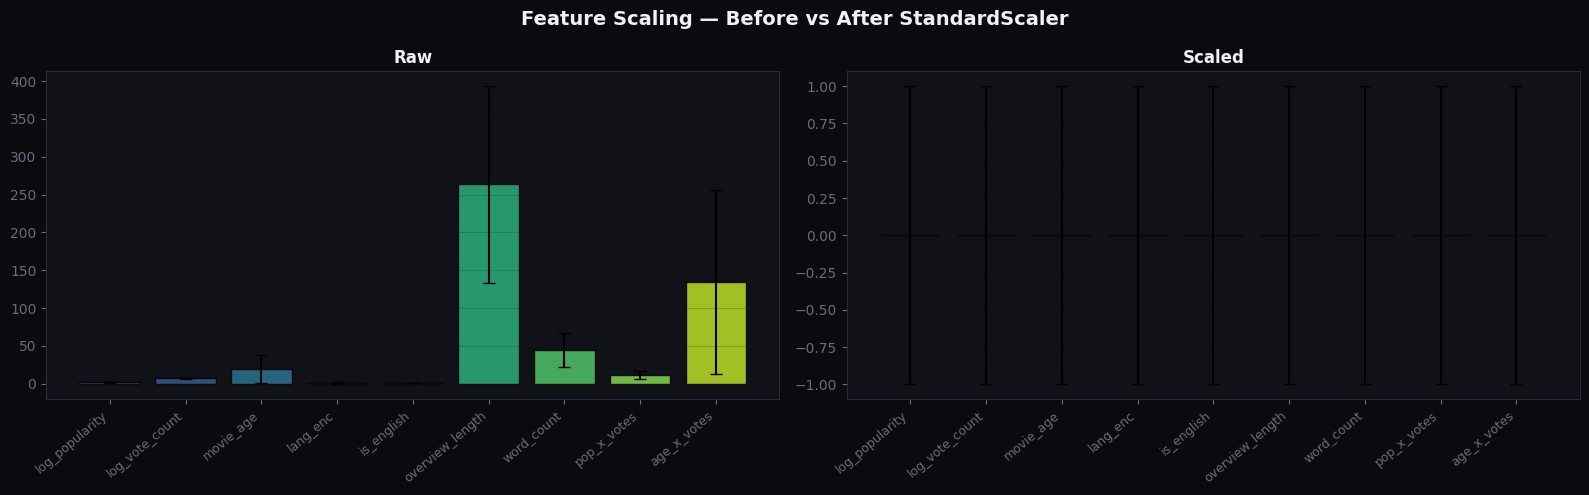

Train: 8,000 | Test: 2,000
Scaler saved successfully!


In [12]:
# ── Train / Test Split & Scaling ──────────────────────────────────────

X = df[FEATURES]
y = df['rating_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

le_t = LabelEncoder()
y_train_e = le_t.fit_transform(y_train)
y_test_e = le_t.transform(y_test)

# Scaling visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    "Feature Scaling — Before vs After StandardScaler",
    fontsize=14,
    fontweight='bold'
)

for ax, data, title in zip(axes, [X_train, X_train_s], ['Raw', 'Scaled']):
    ax.bar(
        range(len(FEATURES)),
        data.mean(),
        yerr=data.std(),
        color=plt.cm.viridis(np.linspace(0.2, 0.9, len(FEATURES))),
        alpha=0.85,
        edgecolor='black',
        capsize=4
    )

    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels(FEATURES, rotation=40, ha='right', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le_t, f)

print("Scaler saved successfully!")

## 🤖 Step 7 — 9 Baseline Models

In [13]:
# ── 9 Baseline Models ────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

BASELINE_MODELS = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost':             AdaBoostClassifier(n_estimators=150, random_state=42),
    'KNN':                  KNeighborsClassifier(n_neighbors=9, n_jobs=-1),
    'SVM (RBF)':            SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes':          GaussianNB(),
}

print(f"{'Model':<26} {'Acc':>8} {'F1':>8} {'MCC':>8} {'CV':>9}")
print('─' * 65)
bl_res = {}
for name, model in BASELINE_MODELS.items():
    model.fit(X_train_s, y_train)
    yp  = model.predict(X_test_s)
    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp, average='weighted')
    mcc = matthews_corrcoef(y_test, yp)
    cv  = cross_val_score(model, X_train_s, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    slug = name.lower().replace(' ','_').replace('(','').replace(')','')
    with open(f'models/baseline_{slug}.pkl','wb') as f: pickle.dump(model, f)
    bl_res[name] = dict(acc=acc, f1=f1, mcc=mcc, cv=cv.mean())
    print(f"{name:<26} {acc:>8.4f} {f1:>8.4f} {mcc:>8.4f} {cv.mean():>9.4f}")
print("\nAll 9 baseline models saved")


Model                           Acc       F1      MCC        CV
─────────────────────────────────────────────────────────────────
Logistic Regression          0.5655   0.5546   0.2418    0.5560
Decision Tree                0.5735   0.5624   0.2883    0.5463
Random Forest                0.5710   0.5685   0.2689    0.5680
Extra Trees                  0.5565   0.5547   0.2468    0.5585
Gradient Boosting            0.5955   0.5905   0.3069    0.5744
AdaBoost                     0.5580   0.5357   0.2320    0.5567
KNN                          0.5530   0.5490   0.2387    0.5505
SVM (RBF)                    0.5860   0.5780   0.2836    0.5796
Naive Bayes                  0.5680   0.5624   0.2948    0.5419

All 9 baseline models saved


## ⚡ Step 8 — XGBoost & LightGBM

In [14]:
# ── XGBoost & LightGBM ───────────────────────────────────────────────
xgb_m = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_m.fit(X_train_s, y_train_e, eval_set=[(X_test_s, y_test_e)], verbose=False)
yp_xgb = le_t.inverse_transform(xgb_m.predict(X_test_s))
print(f"XGBoost  Acc={accuracy_score(y_test,yp_xgb):.4f}  F1={f1_score(y_test,yp_xgb,average='weighted'):.4f}")
with open('models/xgboost.pkl','wb') as f: pickle.dump(xgb_m, f)

lgb_m = lgb.LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
lgb_m.fit(X_train_s, y_train_e,
    eval_set=[(X_test_s, y_test_e)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
yp_lgb = le_t.inverse_transform(lgb_m.predict(X_test_s))
print(f"LightGBM Acc={accuracy_score(y_test,yp_lgb):.4f}  F1={f1_score(y_test,yp_lgb,average='weighted'):.4f}")
with open('models/lightgbm.pkl','wb') as f: pickle.dump(lgb_m, f)


XGBoost  Acc=0.5935  F1=0.5892
LightGBM Acc=0.6070  F1=0.6023


## 🔬 Step 9 — Optuna: Tune RF

In [15]:
# ── Optuna: Tune Random Forest ────────────────────────────────────────
def obj_rf(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',80,300),
             max_depth=trial.suggest_int('max_depth',4,12),
             min_samples_leaf=trial.suggest_int('min_samples_leaf',1,8),
             max_features=trial.suggest_categorical('max_features',['sqrt','log2']))
    return cross_val_score(RandomForestClassifier(**p,random_state=42,n_jobs=-1),
                           X_train_s, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(obj_rf, n_trials=20, show_progress_bar=True)
print(f"RF  best_cv={study_rf.best_value:.4f}  {study_rf.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]

RF  best_cv=0.5863  {'n_estimators': 162, 'max_depth': 12, 'min_samples_leaf': 8, 'max_features': 'log2'}


## 🔬 Step 10 — Optuna: Tune XGBoost

In [16]:
# ── Optuna: Tune XGBoost ─────────────────────────────────────────────
def obj_xgb(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',80,300),
             max_depth=trial.suggest_int('max_depth',3,8),
             learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True),
             subsample=trial.suggest_float('subsample',0.6,1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree',0.6,1.0),
             min_child_weight=trial.suggest_int('min_child_weight',1,8),
             gamma=trial.suggest_float('gamma',0,3))
    return cross_val_score(xgb.XGBClassifier(**p,eval_metric='mlogloss',random_state=42,n_jobs=-1),
                           X_train_s, y_train_e, cv=3, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(obj_xgb, n_trials=20, show_progress_bar=True)
print(f"XGB best_cv={study_xgb.best_value:.4f}  {study_xgb.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]

XGB best_cv=0.5849  {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.0415642850285765, 'subsample': 0.7702629122212667, 'colsample_bytree': 0.7314111324489951, 'min_child_weight': 8, 'gamma': 1.2519398605733145}


## 🔬 Step 11 — Optuna: Tune LightGBM

In [17]:
# ── Optuna: Tune LightGBM ────────────────────────────────────────────
def obj_lgb(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',80,300),
             max_depth=trial.suggest_int('max_depth',3,8),
             learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True),
             num_leaves=trial.suggest_int('num_leaves',20,100),
             subsample=trial.suggest_float('subsample',0.6,1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree',0.6,1.0),
             min_child_samples=trial.suggest_int('min_child_samples',5,40))
    return cross_val_score(lgb.LGBMClassifier(**p,random_state=42,n_jobs=-1,verbose=-1),
                           X_train_s, y_train_e, cv=3, scoring='accuracy', n_jobs=-1).mean()

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(obj_lgb, n_trials=20, show_progress_bar=True)
print(f"LGB best_cv={study_lgb.best_value:.4f}  {study_lgb.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]

LGB best_cv=0.5805  {'n_estimators': 217, 'max_depth': 3, 'learning_rate': 0.05374708354066877, 'num_leaves': 54, 'subsample': 0.8870073727974613, 'colsample_bytree': 0.7003534242760916, 'min_child_samples': 35}


## 🏋️ Step 12 — Retrain Best + Ensemble

In [18]:
# ── Retrain with best params & build Ensemble ───────────────────────
rf_t = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_t.fit(X_train_s, y_train); y_rft = rf_t.predict(X_test_s)
print(f"RF  Tuned  Acc={accuracy_score(y_test,y_rft):.4f}  F1={f1_score(y_test,y_rft,average='weighted'):.4f}")
with open('models/tuned_rf.pkl','wb') as f: pickle.dump(rf_t, f)

xgb_t = xgb.XGBClassifier(**study_xgb.best_params, eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_t.fit(X_train_s, y_train_e); y_xgbt = le_t.inverse_transform(xgb_t.predict(X_test_s))
print(f"XGB Tuned  Acc={accuracy_score(y_test,y_xgbt):.4f}  F1={f1_score(y_test,y_xgbt,average='weighted'):.4f}")
with open('models/tuned_xgboost.pkl','wb') as f: pickle.dump(xgb_t, f)

lgb_t = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)
lgb_t.fit(X_train_s, y_train_e); y_lgbt = le_t.inverse_transform(lgb_t.predict(X_test_s))
print(f"LGB Tuned  Acc={accuracy_score(y_test,y_lgbt):.4f}  F1={f1_score(y_test,y_lgbt,average='weighted'):.4f}")
with open('models/tuned_lightgbm.pkl','wb') as f: pickle.dump(lgb_t, f)

ens = VotingClassifier(
    estimators=[('rf',rf_t),('gb',BASELINE_MODELS['Gradient Boosting']),('svm',BASELINE_MODELS['SVM (RBF)'])],
    voting='soft')
ens.fit(X_train_s, y_train); y_ens = ens.predict(X_test_s)
print(f"Ensemble   Acc={accuracy_score(y_test,y_ens):.4f}  F1={f1_score(y_test,y_ens,average='weighted'):.4f}")
with open('models/ensemble.pkl','wb') as f: pickle.dump(ens, f)
print("All tuned models + ensemble saved")


RF  Tuned  Acc=0.5995  F1=0.5945
XGB Tuned  Acc=0.6000  F1=0.5956
LGB Tuned  Acc=0.6075  F1=0.6019
Ensemble   Acc=0.6005  F1=0.5949
All tuned models + ensemble saved


## 🎯 Step 13 — Confusion Matrices

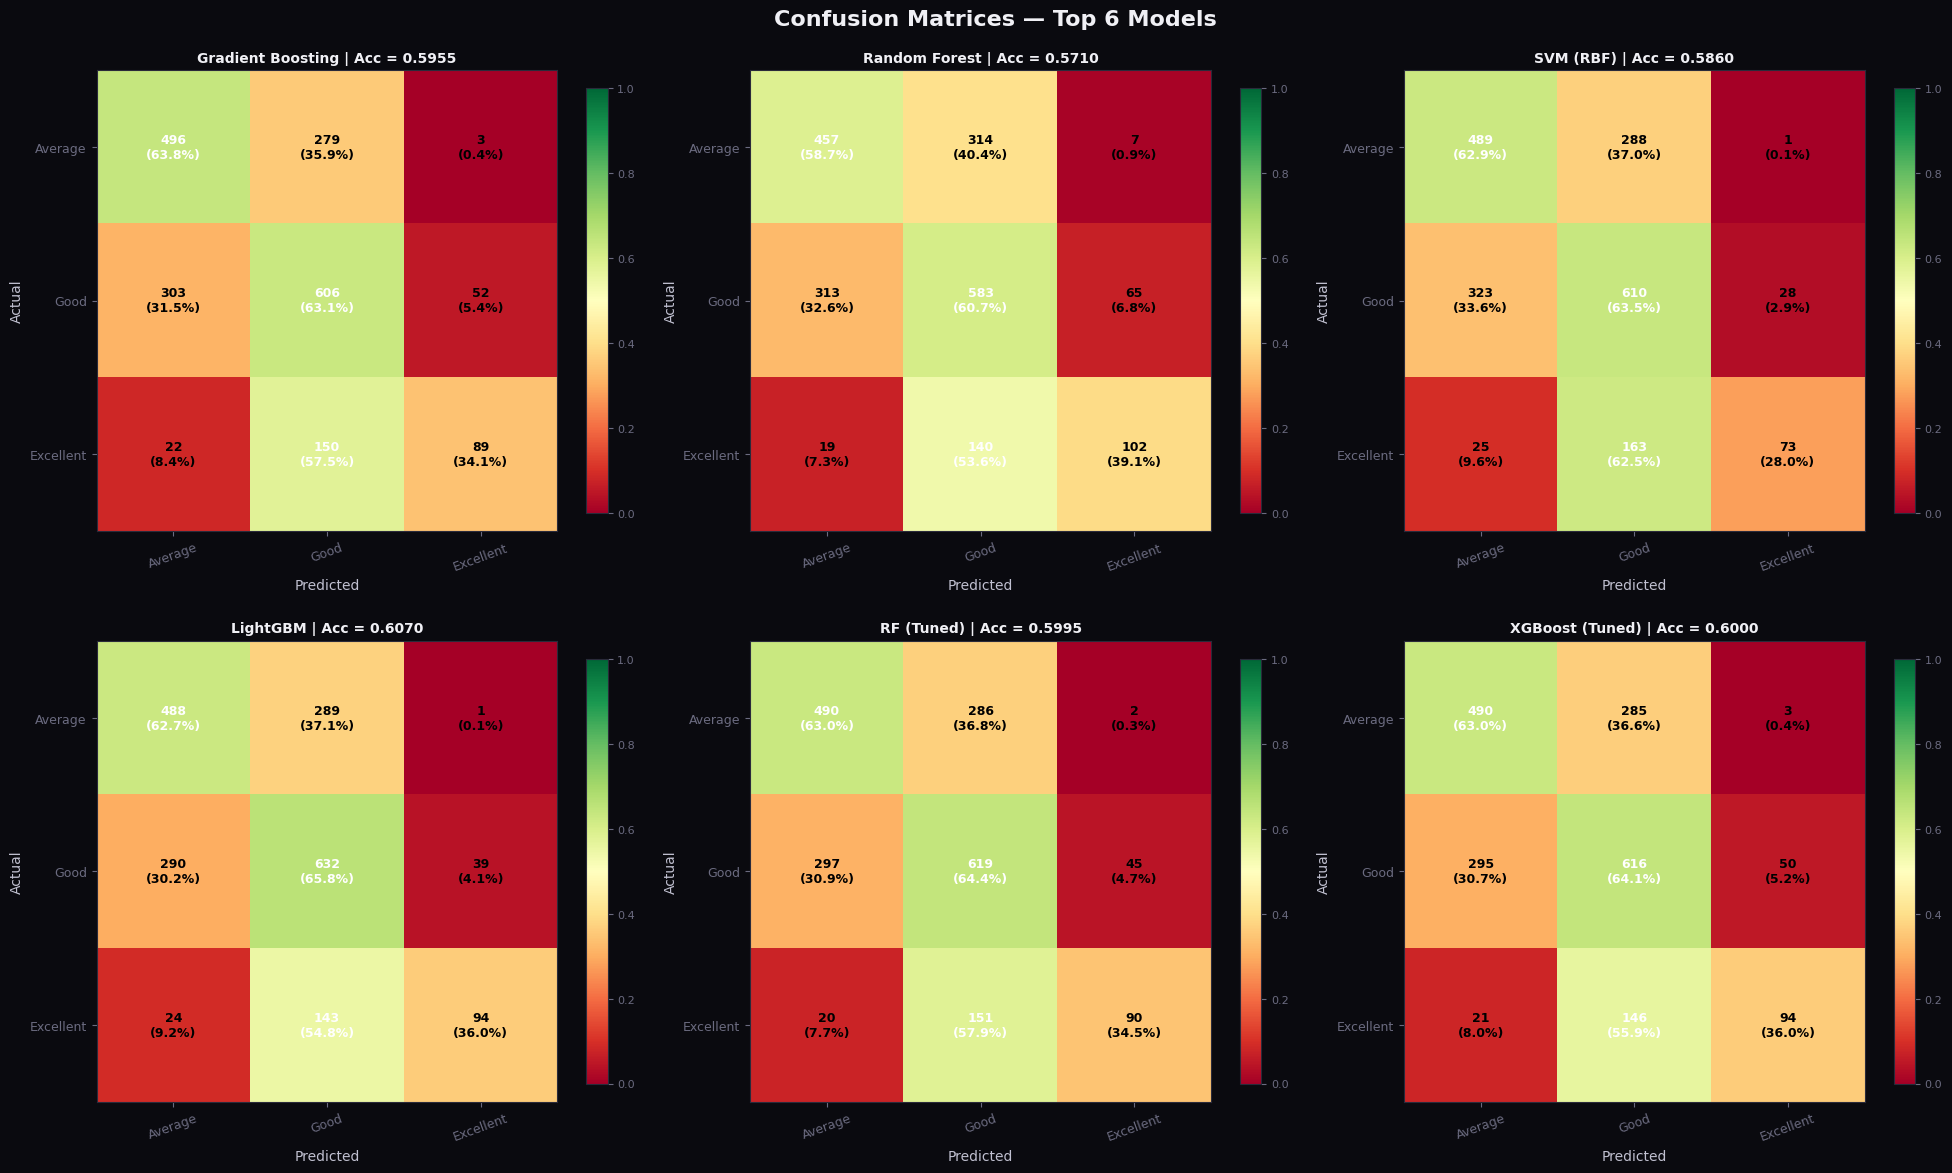

In [19]:
# ──  Confusion Matrices ─────────────────────────────────────

pmap = {
    'Gradient Boosting': BASELINE_MODELS['Gradient Boosting'].predict(X_test_s),
    'Random Forest': BASELINE_MODELS['Random Forest'].predict(X_test_s),
    'SVM (RBF)': BASELINE_MODELS['SVM (RBF)'].predict(X_test_s),
    'LightGBM': le_t.inverse_transform(lgb_m.predict(X_test_s)),
    'RF (Tuned)': y_rft,
    'XGBoost (Tuned)': y_xgbt,
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0a0a0f')

fig.suptitle(
    'Confusion Matrices — Top 6 Models',
    fontsize=16,
    fontweight='bold',
    color='#f0f0f5'
)

for ax, (name, preds) in zip(axes.flat, pmap.items()):

    ax.set_facecolor('#111118')

    cm = confusion_matrix(
        y_test,
        preds,
        labels=CLASSES
    )

    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Better premium color palette
    im = ax.imshow(
        cm_n,
        cmap='RdYlGn',
        vmin=0,
        vmax=1
    )

    # Better visible text
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            value = cm_n[i, j]

            ax.text(
                j,
                i,
                f"{cm[i,j]}\n({value:.1%})",
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='white' if value > 0.45 else 'black'
            )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(
        CLASSES,
        rotation=20,
        fontsize=9
    )

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(
        CLASSES,
        fontsize=9
    )

    acc = accuracy_score(y_test, preds)

    ax.set_title(
        f"{name} | Acc = {acc:.4f}",
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

## 🌟 Step 14 — Feature Importance & Learning Curves

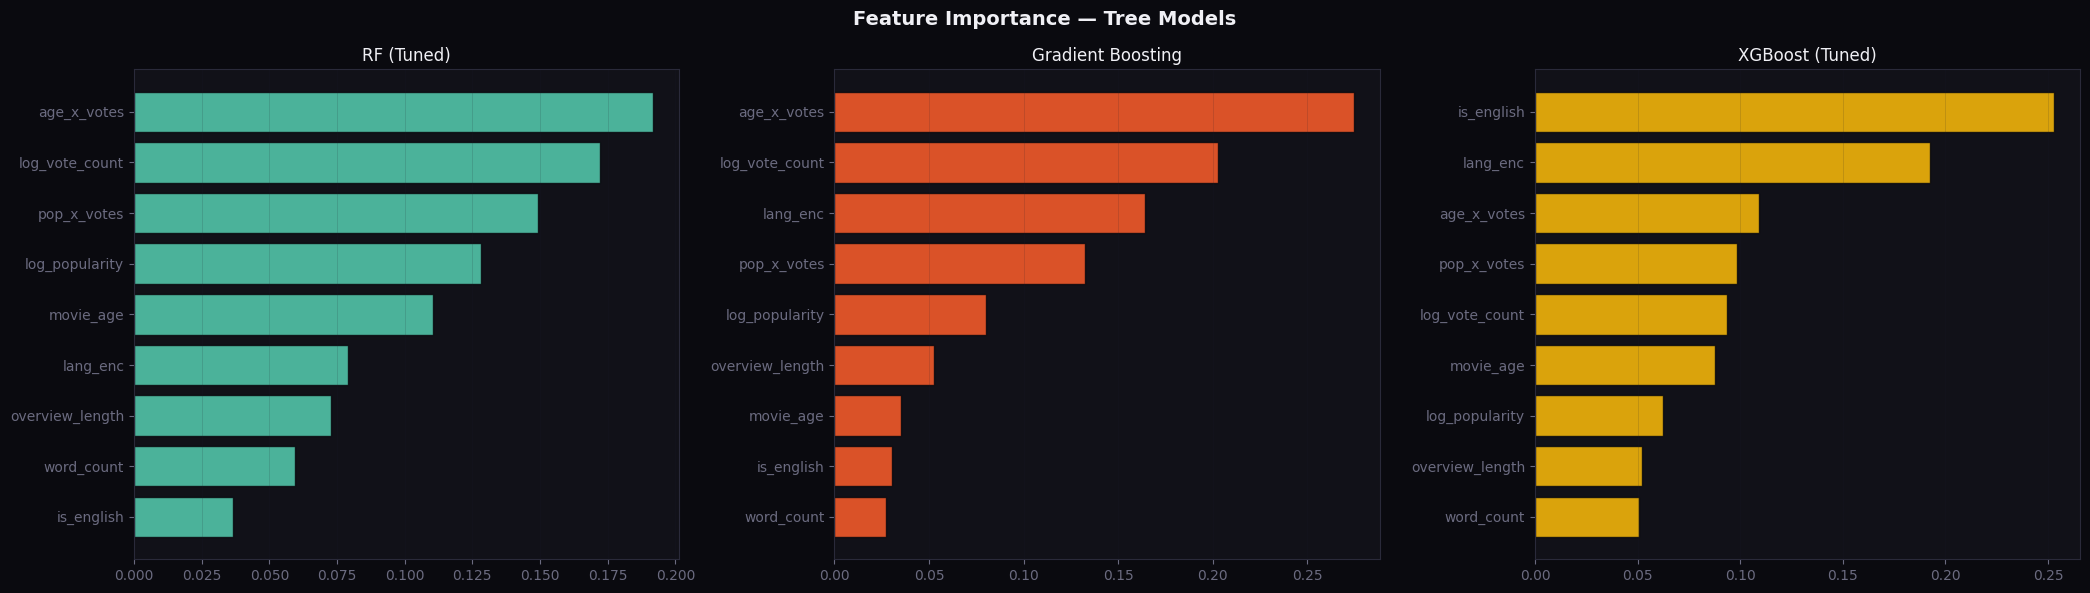

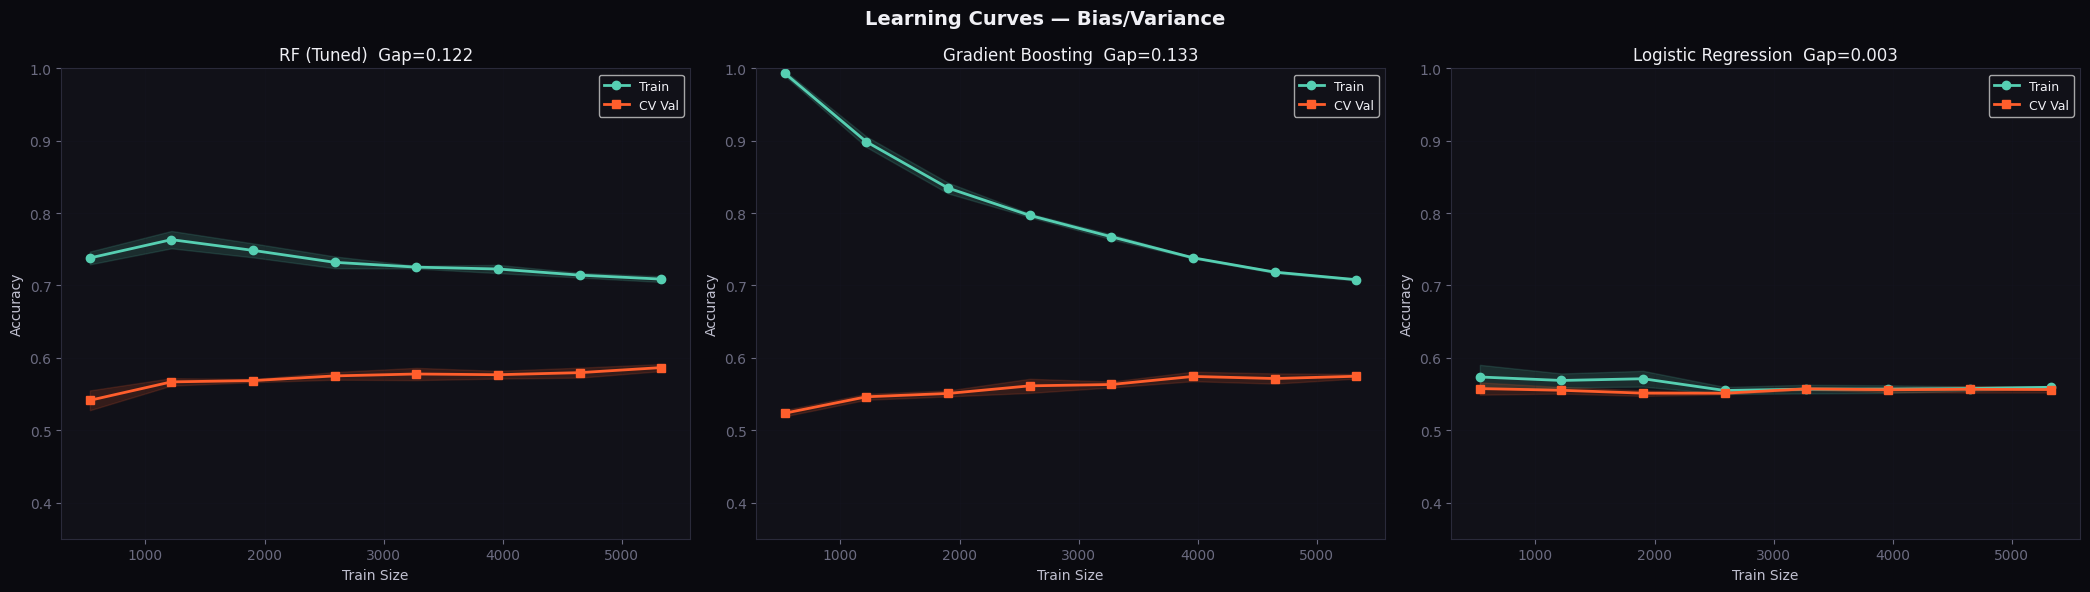

In [20]:
# ── Feature Importance & Learning Curves ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Feature Importance — Tree Models', fontsize=14, fontweight='bold', color='#f0f0f5')
for ax, (model, name, clr) in zip(axes, [
    (rf_t,  'RF (Tuned)',        '#56cfb2'),
    (BASELINE_MODELS['Gradient Boosting'], 'Gradient Boosting', '#ff5e2c'),
    (xgb_t, 'XGBoost (Tuned)',   '#ffbe0b'),
]):
    imp = model.feature_importances_; idx = np.argsort(imp)
    ax.barh([FEATURES[i] for i in idx], imp[idx], color=clr, alpha=0.85, edgecolor='#0a0a0f')
    ax.set_title(name); ax.set_facecolor('#111118'); ax.grid(True, alpha=0.2, axis='x')
fig.patch.set_facecolor('#0a0a0f'); plt.tight_layout(); plt.show()

# Learning curves
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Learning Curves — Bias/Variance', fontsize=14, fontweight='bold', color='#f0f0f5')
for ax, (model, name) in zip(axes, [
    (rf_t,  'RF (Tuned)'),
    (BASELINE_MODELS['Gradient Boosting'], 'Gradient Boosting'),
    (BASELINE_MODELS['Logistic Regression'], 'Logistic Regression'),
]):
    ts, tr, vr = learning_curve(model, X_train_s, y_train, cv=3, n_jobs=-1,
                                 train_sizes=np.linspace(0.1, 1.0, 8), scoring='accuracy')
    tm, ts2 = tr.mean(1), tr.std(1); vm, vs = vr.mean(1), vr.std(1)
    ax.plot(ts, tm, 'o-', color='#56cfb2', lw=2, label='Train')
    ax.fill_between(ts, tm-ts2, tm+ts2, alpha=0.15, color='#56cfb2')
    ax.plot(ts, vm, 's-', color='#ff5e2c', lw=2, label='CV Val')
    ax.fill_between(ts, vm-vs, vm+vs, alpha=0.15, color='#ff5e2c')
    ax.set_title(f'{name}  Gap={tm[-1]-vm[-1]:.3f}')
    ax.set_xlabel('Train Size'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9); ax.set_facecolor('#111118'); ax.grid(True, alpha=0.2); ax.set_ylim(0.35, 1.0)
fig.patch.set_facecolor('#0a0a0f'); plt.tight_layout(); plt.show()


## 📐 Step 15 — ROC Curves (OvR)

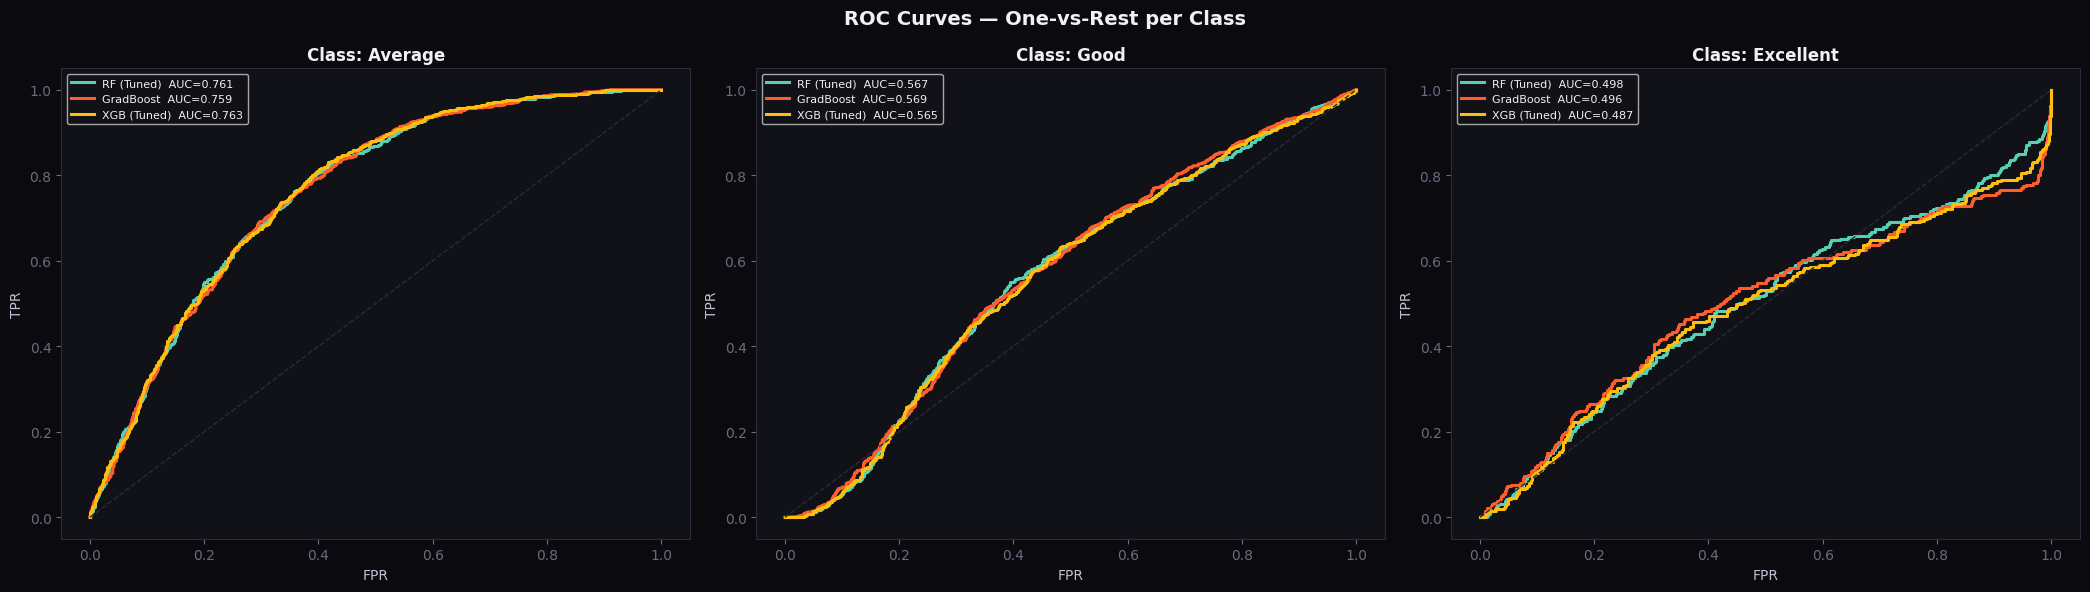

In [21]:
# ── ROC Curves (One-vs-Rest) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('ROC Curves — One-vs-Rest per Class', fontsize=14, fontweight='bold', color='#f0f0f5')
for ai, cls in enumerate(CLASSES):
    ax = axes[ai]; ci = ai
    for model, name, clr, yref in [
        (rf_t,  'RF (Tuned)',   '#56cfb2', y_test),
        (BASELINE_MODELS['Gradient Boosting'], 'GradBoost', '#ff5e2c', y_test),
        (xgb_t, 'XGB (Tuned)', '#ffbe0b', le_t.inverse_transform(y_test_e)),
    ]:
        pr  = model.predict_proba(X_test_s)
        yb  = (np.array([str(v) for v in yref]) == cls).astype(int)
        fpr, tpr, _ = roc_curve(yb, pr[:, ci])
        ra  = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2.2, color=clr, label=f'{name}  AUC={ra:.3f}')
    ax.plot([0,1],[0,1],'--', color='#2a2a3a', lw=1)
    ax.set_title(f'Class: {cls}', fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8); ax.set_facecolor('#111118'); ax.grid(True, alpha=0.2)
fig.patch.set_facecolor('#0a0a0f'); plt.tight_layout(); plt.show()


## 📊 Step 16 — Per-Class Metrics

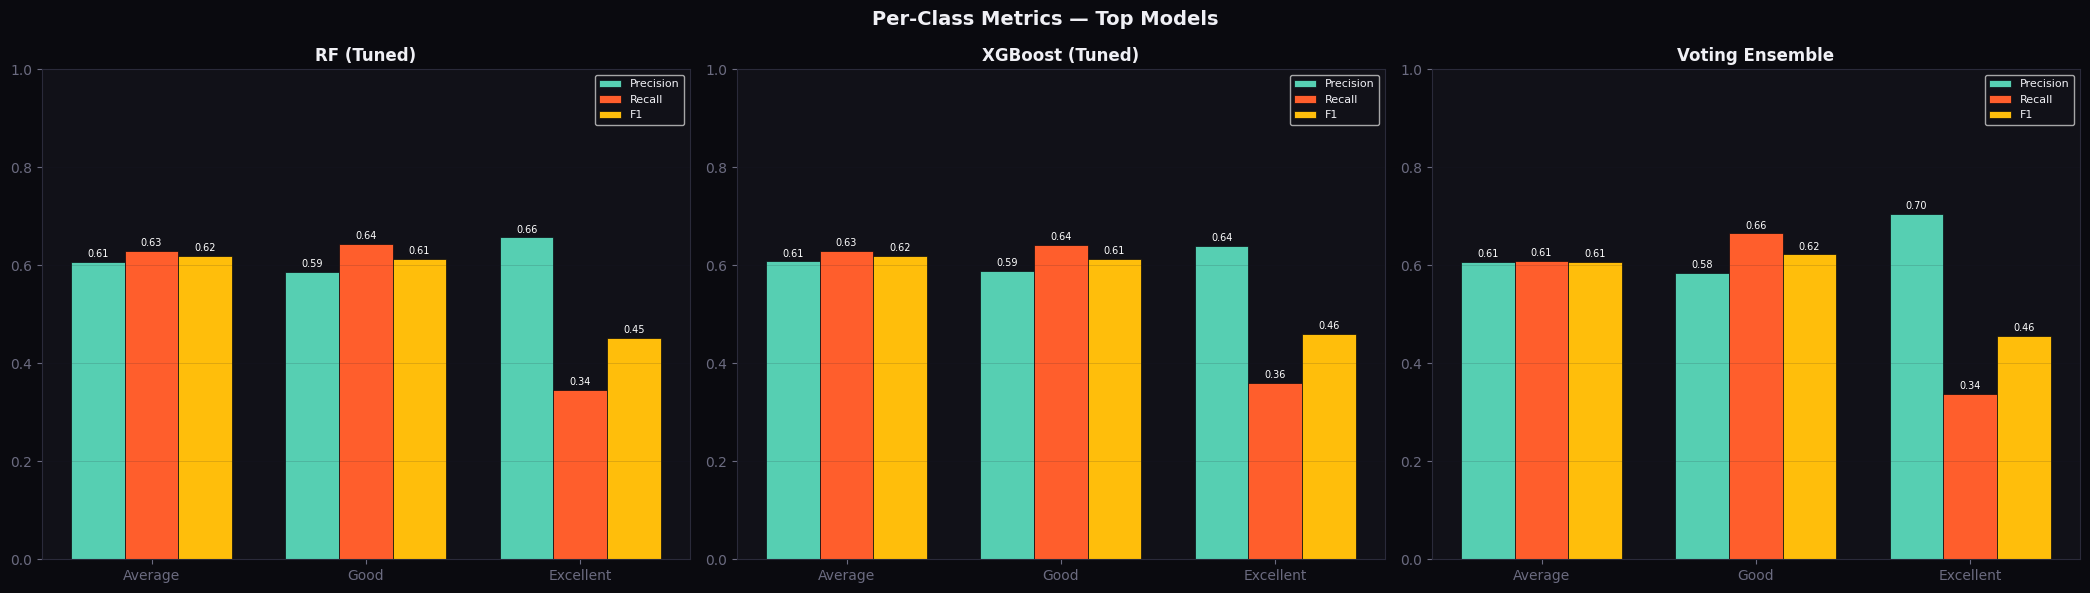

In [22]:
# ── Per-class Precision / Recall / F1 ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Per-Class Metrics — Top Models', fontsize=14, fontweight='bold', color='#f0f0f5')
for ax, (mname, yp) in zip(axes, [
    ('RF (Tuned)',      y_rft),
    ('XGBoost (Tuned)', y_xgbt),
    ('Voting Ensemble', y_ens),
]):
    rep  = classification_report(y_test, yp, output_dict=True, zero_division=0)
    x = np.arange(3); w = 0.25
    prec = [rep.get(c,{}).get('precision',0) for c in CLASSES]
    rec  = [rep.get(c,{}).get('recall',0)    for c in CLASSES]
    f1v  = [rep.get(c,{}).get('f1-score',0)  for c in CLASSES]
    ax.bar(x-w, prec, w, label='Precision', color='#56cfb2', edgecolor='#0a0a0f', linewidth=0.5)
    ax.bar(x,   rec,  w, label='Recall',    color='#ff5e2c', edgecolor='#0a0a0f', linewidth=0.5)
    ax.bar(x+w, f1v,  w, label='F1',        color='#ffbe0b', edgecolor='#0a0a0f', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(CLASSES, fontsize=10); ax.set_ylim(0, 1)
    ax.set_title(mname, fontweight='bold'); ax.legend(fontsize=8)
    ax.set_facecolor('#111118'); ax.grid(True, alpha=0.2, axis='y')
    for i, vals in enumerate([prec, rec, f1v]):
        for xi, v in enumerate(vals):
            ax.text(xi+(i-1)*w, v+0.01, f'{v:.2f}', ha='center', fontsize=7, color='white')
fig.patch.set_facecolor('#0a0a0f'); plt.tight_layout(); plt.show()


## 🏆 Step 17 — Final Leaderboard

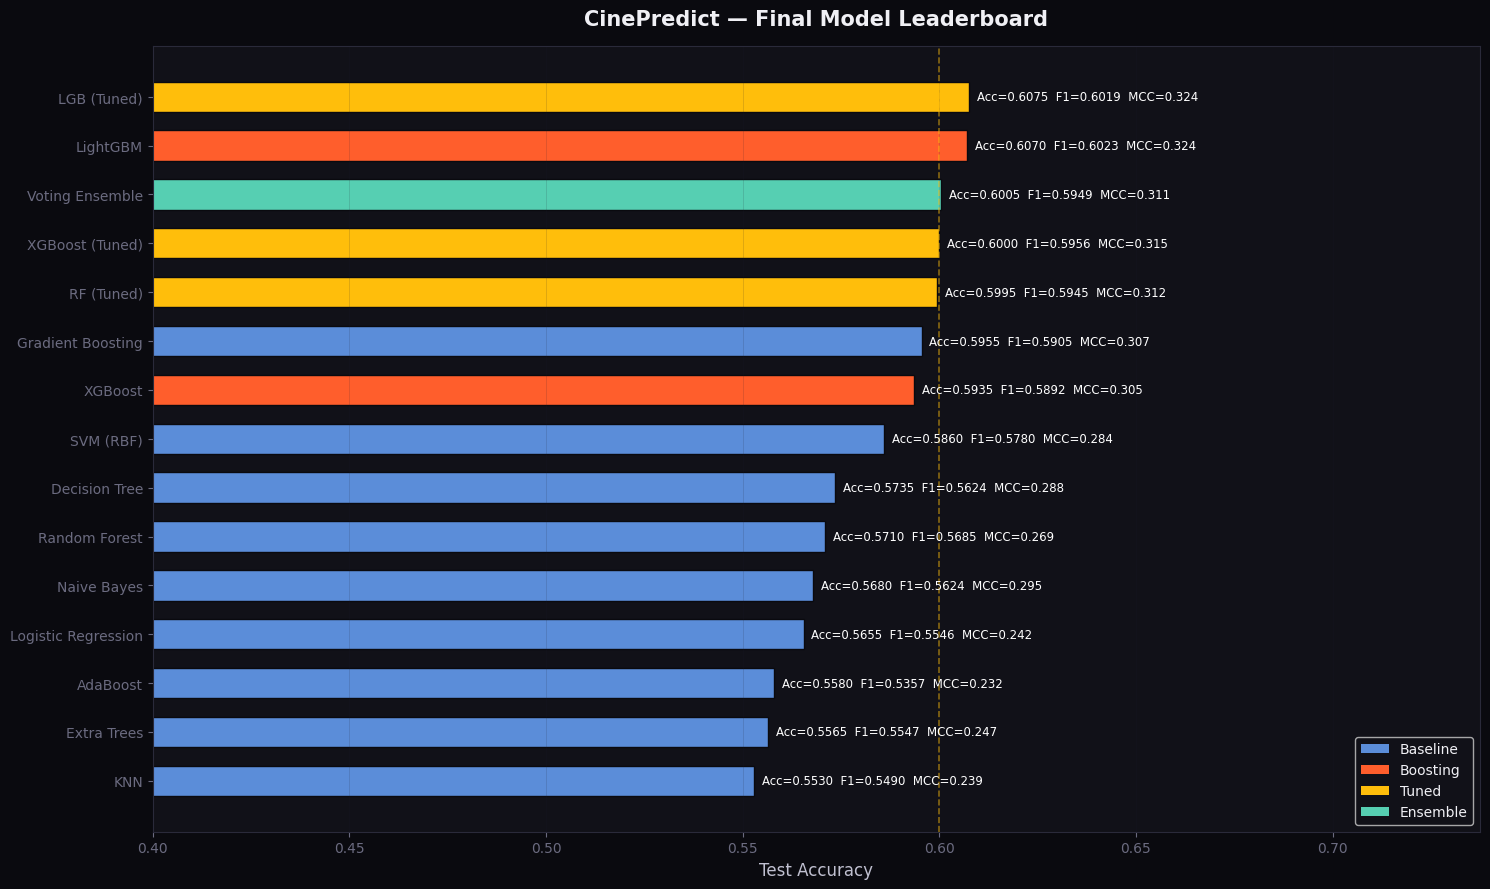

  CINEPREDCT — FINAL LEADERBOARD
                  Model      Type  Accuracy      F1     MCC
1           LGB (Tuned)     Tuned    0.6075  0.6019  0.3241
2              LightGBM  Boosting    0.6070  0.6023  0.3242
3       Voting Ensemble  Ensemble    0.6005  0.5949  0.3106
4       XGBoost (Tuned)     Tuned    0.6000  0.5956  0.3145
5            RF (Tuned)     Tuned    0.5995  0.5945  0.3119
6     Gradient Boosting  Baseline    0.5955  0.5905  0.3069
7               XGBoost  Boosting    0.5935  0.5892  0.3048
8             SVM (RBF)  Baseline    0.5860  0.5780  0.2836
9         Decision Tree  Baseline    0.5735  0.5624  0.2883
10        Random Forest  Baseline    0.5710  0.5685  0.2689
11          Naive Bayes  Baseline    0.5680  0.5624  0.2948
12  Logistic Regression  Baseline    0.5655  0.5546  0.2418
13             AdaBoost  Baseline    0.5580  0.5357  0.2320
14          Extra Trees  Baseline    0.5565  0.5547  0.2468
15                  KNN  Baseline    0.5530  0.5490  0.2387

 Best 

In [23]:
# ── Final Leaderboard ────────────────────────────────────────────────
rows = []
for name, model in {**BASELINE_MODELS, 'XGBoost':xgb_m, 'LightGBM':lgb_m}.items():
    yp = le_t.inverse_transform(model.predict(X_test_s)) if name in ['XGBoost','LightGBM'] else model.predict(X_test_s)
    tp = 'Boosting' if name in ['XGBoost','LightGBM'] else 'Baseline'
    rows.append(dict(Model=name, Type=tp,
        Accuracy=round(accuracy_score(y_test,yp),4),
        F1=round(f1_score(y_test,yp,average='weighted'),4),
        MCC=round(matthews_corrcoef(y_test,yp),4)))
for label, yp, tp in [
    ('RF (Tuned)',       y_rft,  'Tuned'),
    ('XGBoost (Tuned)', y_xgbt, 'Tuned'),
    ('LGB (Tuned)',     y_lgbt, 'Tuned'),
    ('Voting Ensemble', y_ens,  'Ensemble'),
]:
    rows.append(dict(Model=label, Type=tp,
        Accuracy=round(accuracy_score(y_test,yp),4),
        F1=round(f1_score(y_test,yp,average='weighted'),4),
        MCC=round(matthews_corrcoef(y_test,yp),4)))

summary = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary.index += 1

# Visualise
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(15, 9))
top_n  = summary.sort_values('Accuracy')
CMAP   = {'Baseline':'#5b8dd9','Boosting':'#ff5e2c','Tuned':'#ffbe0b','Ensemble':'#56cfb2'}
colors = [CMAP.get(t,'#6b6b80') for t in top_n['Type']]
bars   = ax.barh(top_n['Model'], top_n['Accuracy'], color=colors, height=0.62, edgecolor='#0a0a0f')
for bar, (_, row) in zip(bars, top_n.iterrows()):
    ax.text(row['Accuracy']+0.002, bar.get_y()+bar.get_height()/2,
            f'Acc={row["Accuracy"]:.4f}  F1={row["F1"]:.4f}  MCC={row["MCC"]:.3f}',
            va='center', fontsize=8.5, color='white')
ax.set_xlim(0.40, top_n['Accuracy'].max()+0.13)
ax.set_title('CinePredict — Final Model Leaderboard', fontsize=15, fontweight='bold', color='#f0f0f5', pad=15)
ax.set_xlabel('Test Accuracy', fontsize=12)
leg = [Patch(facecolor=v, label=k) for k,v in CMAP.items()]
ax.legend(handles=leg, loc='lower right', fontsize=10)
ax.set_facecolor('#111118'); ax.grid(True, alpha=0.2, axis='x')
ax.axvline(0.60, color='#ffbe0b', linestyle='--', lw=1.2, alpha=0.5)
fig.patch.set_facecolor('#0a0a0f'); plt.tight_layout(); plt.show()

print("=" * 60)
print("  CINEPREDCT — FINAL LEADERBOARD")
print("=" * 60)
print(summary.to_string())
print(f"\n Best Model : {summary.iloc[0]['Model']}")
print(f" Accuracy   : {summary.iloc[0]['Accuracy']:.4f}")

with open('models/final_results.json','w') as f:
    import json; json.dump(summary.to_dict(orient='records'), f, indent=2)
print("\nRun: python app.py  → open http://127.0.0.1:5000")


# Task
Refactor the notebook by encapsulating all code from 'Step 3 — EDA: Distributions' and 'Step 4 — Correlation Heatmap' into a Python function named `perform_eda(df)`. After defining this function, call it using `perform_eda(df.copy())` in a new code cell.

Next, encapsulate all code from 'Step 5 — Feature Engineering' through 'Step 17 — Final Leaderboard' into a Python function named `run_model_pipeline(df)`. After defining this function, call it using `run_model_pipeline(df)` in a new code cell.

Finally, remove all original code cells that have been moved into these functions, keeping only the necessary text cells and the calls to the new functions. This ensures a clear separation and modularization of the EDA and model building logic.

## Create EDA Function

### Subtask:
Encapsulate all code from 'Step 3 — EDA: Distributions' and 'Step 4 — Correlation Heatmap' into a Python function named `perform_eda(df)` in a new code cell. This function will be responsible for generating all the EDA plots and analyses.
